In [ ]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt 
import  seaborn as sns
from dask.distributed import Client
client = Client()  # Automatically uses available cores
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 15.86 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:62435,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:62462,Total threads: 4
Dashboard: http://127.0.0.1:62467/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:62438,


Task exception was never retrieved
future: <Task finished name='Task-132706' coro=<Client._gather.<locals>.wait() done, defined at c:\Users\apoor\anaconda3\Lib\site-packages\distributed\client.py:2384> exception=AllExit()>
Traceback (most recent call last):
  File "c:\Users\apoor\anaconda3\Lib\site-packages\distributed\client.py", line 2393, in wait
    raise AllExit()
distributed.client.AllExit
2025-10-18 14:14:29,188 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 45c8f81c3834da00296dc56a307a36e8 initialized by task ('shuffle-transfer-45c8f81c3834da00296dc56a307a36e8', 28) executed on worker tcp://127.0.0.1:62463
2025-10-18 14:14:58,403 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 45c8f81c3834da00296dc56a307a36e8 deactivated due to stimulus 'task-finished-1760777098.3935277'
Task exception was never retrieved
future: <Task finished name='Task-448939' coro=<Client._gather.<locals>.wait() done, defined at c:\Users\apoor\anaconda3\Lib\site-packages\distributed

In [2]:
df_jan_path = "D:\datascience\campusx\PROJECTS\yellow_tripdata_2016-01.csv\yellow_tripdata_2016-01.csv"
df_feb_path = "D:\datascience\campusx\PROJECTS\yellow_tripdata_2016-02.csv\yellow_tripdata_2016-02.csv"
df_mar_path = "D:\datascience\campusx\PROJECTS\yellow_tripdata_2016-03.csv\yellow_tripdata_2016-03.csv"

In [3]:
# load the dataframes

df_jan = dd.read_csv(df_jan_path, assume_missing=True)
df_feb = dd.read_csv(df_feb_path, assume_missing=True)
df_mar = dd.read_csv(df_mar_path, assume_missing=True)

In [4]:
df_jan

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
npartitions=26,,,,,,,,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


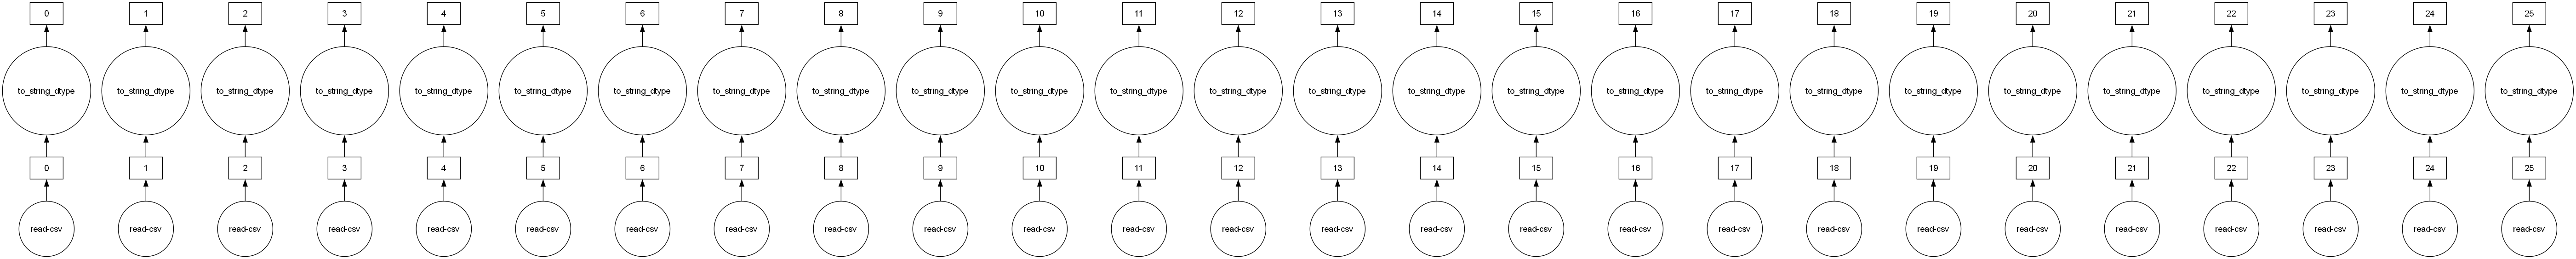

In [5]:
df_jan.visualize(tasks=True)

In [6]:
# shape of all the three datasets

print("Shape of january dataset", df_jan.shape)
print("Shape of february dataset", df_feb.shape)
print("Shape of march dataset", df_mar.shape)

Shape of january dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(8510bae)).size() // 19, dtype=int32>, 19)
Shape of february dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(12b983c)).size() // 19, dtype=int32>, 19)
Shape of march dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(51d14b8)).size() // 19, dtype=int32>, 19)


In [7]:
# concat the three dataframes as one

df_final = dd.concat([df_jan, df_feb, df_mar], axis=0).drop(columns=['extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount', 'payment_type'])

In [8]:
df_final

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=82,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...


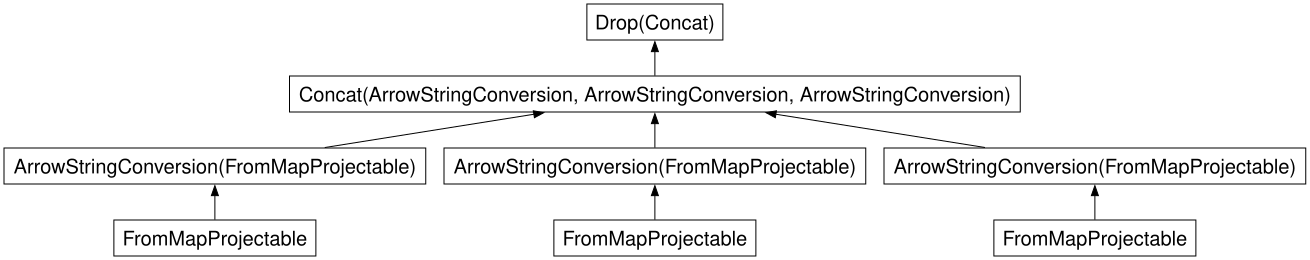

In [9]:
# visulaize the concatenation

df_final.visualize()

In [10]:
# columns in the final dataset

df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='object')

In [11]:
# print top ten rows

df_final.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
0,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,2.0,1.10,-73.990372,40.734695,1.0,N,-73.981842,40.732407,7.5
1,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,5.0,4.90,-73.980782,40.729912,1.0,N,-73.944473,40.716679,18.0
2,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,10.54,-73.984550,40.679565,1.0,N,-73.950272,40.788925,33.0
3,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,4.75,-73.993469,40.718990,1.0,N,-73.962242,40.657333,16.5
4,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,3.0,1.76,-73.960625,40.781330,1.0,N,-73.977264,40.758514,8.0
5,2.0,2016-01-01 00:00:00,2016-01-01 00:18:30,2.0,5.52,-73.980118,40.743050,1.0,N,-73.913490,40.763142,19.0
6,2.0,2016-01-01 00:00:00,2016-01-01 00:26:45,2.0,7.45,-73.994057,40.719990,1.0,N,-73.966362,40.789871,26.0
7,1.0,2016-01-01 00:00:01,2016-01-01 00:11:55,1.0,1.20,-73.979424,40.744614,1.0,N,-73.992035,40.753944,9.0
8,1.0,2016-01-01 00:00:02,2016-01-01 00:11:14,1.0,6.00,-73.947151,40.791046,1.0,N,-73.920769,40.865578,18.0
9,2.0,2016-01-01 00:00:02,2016-01-01 00:11:08,1.0,3.21,-73.998344,40.723896,1.0,N,-73.995850,40.688400,11.5


(<dask_expr.expr.Scalar: expr=(Drop(frame=Concat(frames=[ArrowStringConversion(frame=FromMapProjectable(8510bae)), ArrowStringConversion(frame=FromMapProjectable(12b983c)), ArrowStringConversion(frame=FromMapProjectable(51d14b8))], ), columns=['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'payment_type'])).size() // 12, dtype=int32>,
 12)

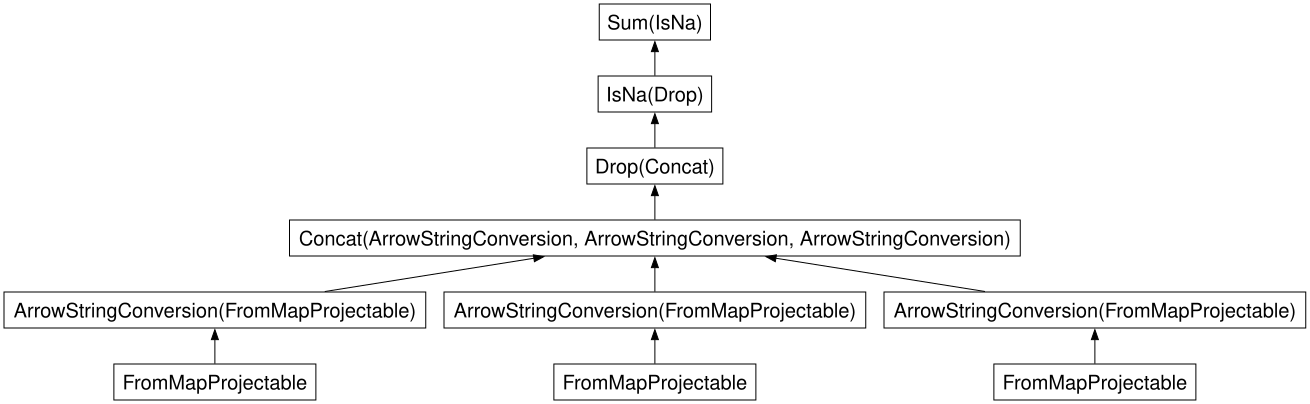

In [13]:
df_final.isna().sum().visualize()

In [14]:
# check for missing values in the data

df_final.isna().sum().compute()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
fare_amount              0
dtype: int64

In [15]:
# datatypes

df_final.dtypes

VendorID                         float64
tpep_pickup_datetime     string[pyarrow]
tpep_dropoff_datetime    string[pyarrow]
passenger_count                  float64
trip_distance                    float64
pickup_longitude                 float64
pickup_latitude                  float64
RatecodeID                       float64
store_and_fwd_flag       string[pyarrow]
dropoff_longitude                float64
dropoff_latitude                 float64
fare_amount                      float64
dtype: object

# Analysis

In [16]:
sns.set_style("whitegrid")

In [17]:
# statistical summary of numerical columns

df_final.describe().compute()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,fare_amount
count,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07
mean,1.532576e+00,1.661700e+00,5.309408e+00,-7.283942e+01,4.012605e+01,1.039150e+00,-7.290482e+01,4.016297e+01,1.257198e+01
std,4.989377e-01,1.316154e+00,4.672575e+03,9.090656e+00,5.007832e+00,5.564537e-01,8.828348e+00,4.863875e+00,9.179006e+01
min,1.000000e+00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-1.616987e+02,-7.703949e+01,-9.576000e+02
25%,1.000000e+00,1.000000e+00,1.100000e+00,-7.399055e+01,4.074137e+01,1.000000e+00,-7.399009e+01,4.074001e+01,7.000000e+00
50%,2.000000e+00,1.000000e+00,1.930000e+00,-7.397922e+01,4.075640e+01,1.000000e+00,-7.397832e+01,4.075612e+01,1.000000e+01
75%,2.000000e+00,2.000000e+00,3.800000e+00,-7.396252e+01,4.076979e+01,1.000000e+00,-7.395599e+01,4.077166e+01,1.550000e+01
max,2.000000e+00,9.000000e+00,1.907263e+07,9.464387e+01,6.685682e+01,9.900000e+01,3.889659e+01,4.053167e+02,4.294967e+05


# Vendor ID

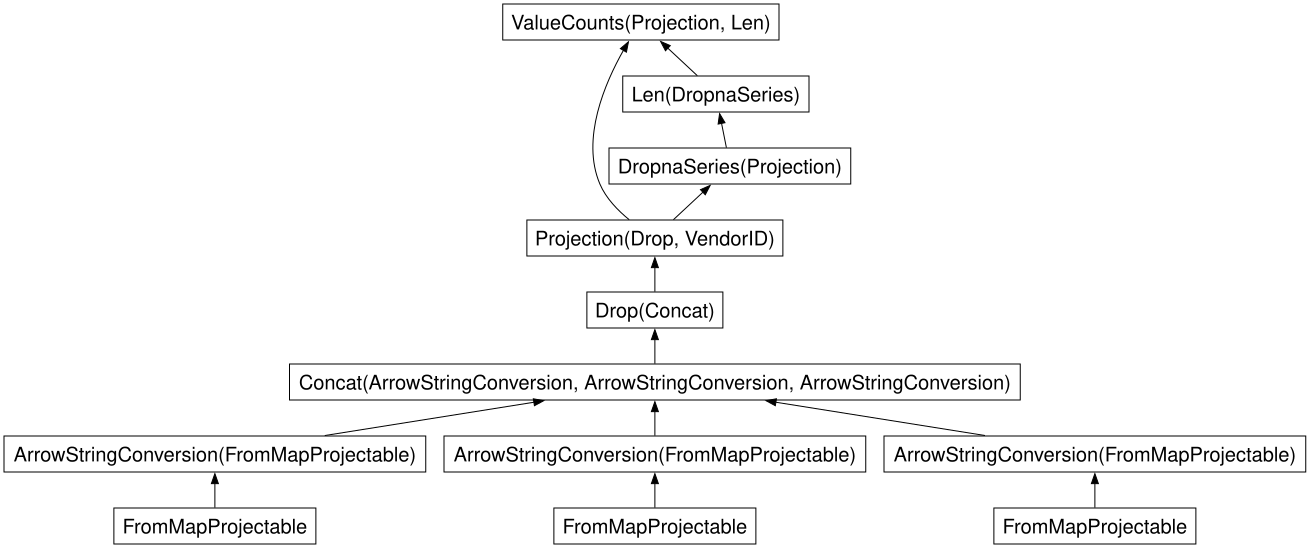

In [18]:
df_final["VendorID"].value_counts(normalize=True).visualize()

In [19]:
# pie chart of vendor share in NYC

vendor_share = (
    df_final["VendorID"]
    .value_counts(normalize=True)
    .compute()
)

In [20]:
type(vendor_share)


pandas.core.series.Series

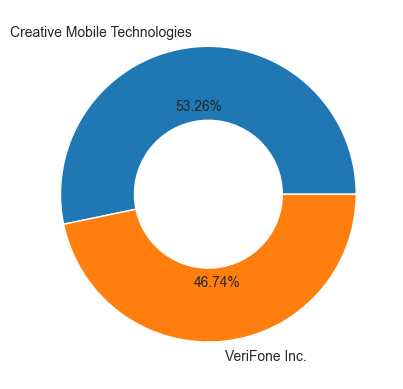

In [21]:
# donut chart

plt.pie(vendor_share, labels=["Creative Mobile Technologies","VeriFone Inc."], autopct="%.2f%%",
       radius=1, wedgeprops=dict(width=0.5, edgecolor="w"))
plt.show()

# Passenger Count

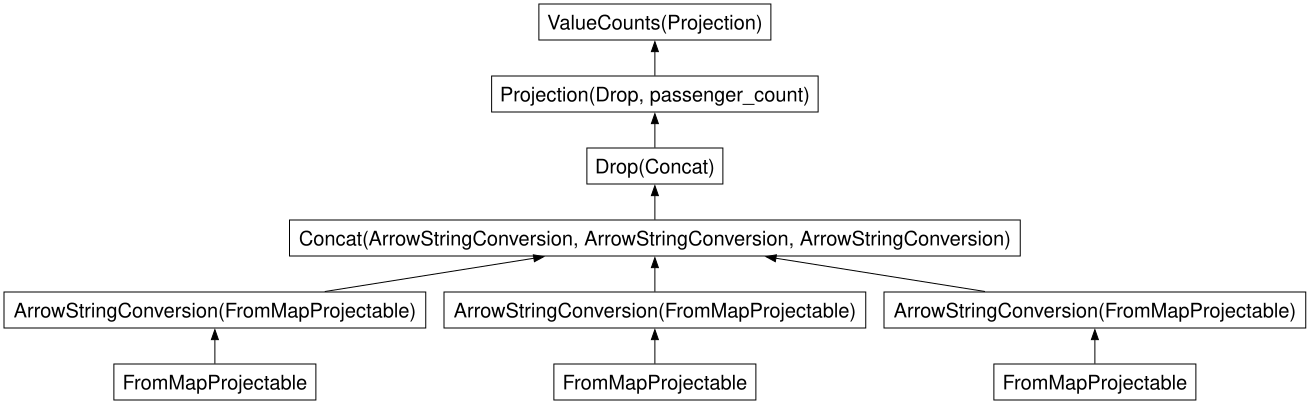

In [22]:
df_final["passenger_count"].value_counts().visualize()

In [23]:
# countplot for passenger plot

passenger_count = df_final["passenger_count"].value_counts().compute()

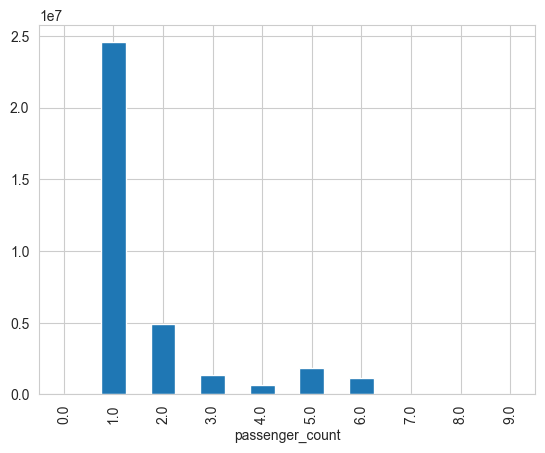

In [24]:
passenger_count.sort_index().plot(kind="bar")
plt.show()

Passenger count value outside the range of 1 to 5 passengers are erroneous and not allowed by the taxi commission in NYC


# Trip Distance 

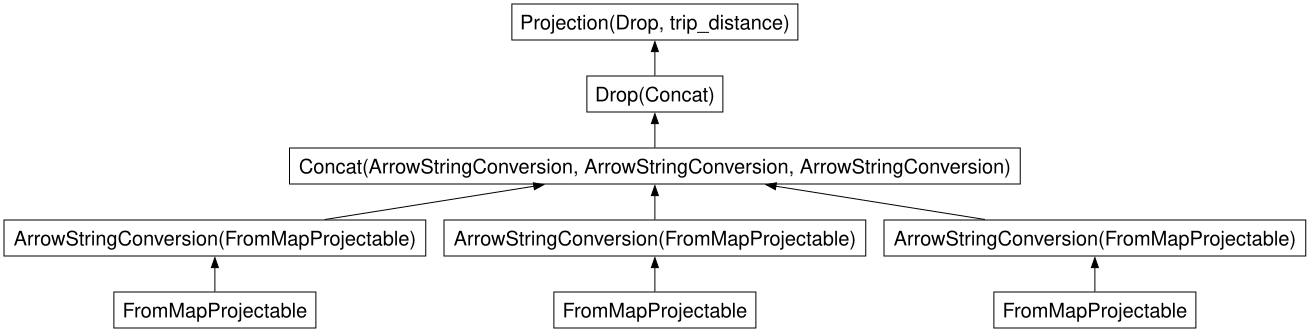

In [25]:
df_final.loc[:,"trip_distance"].visualize()



<Axes: ylabel='trip_distance'>

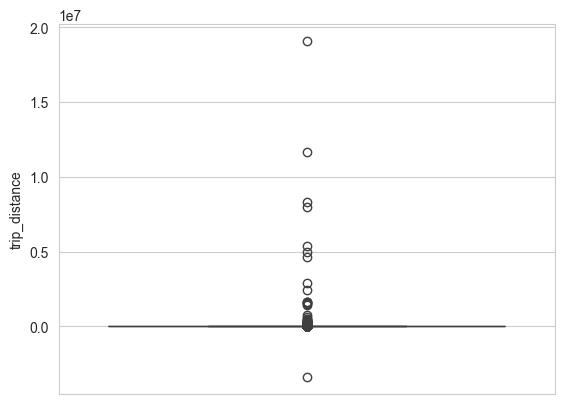

In [26]:
# boxplot for the trip distance

sns.boxplot(df_final.loc[:,"trip_distance"].compute())

In [27]:
df_final["trip_distance"]

Dask Series Structure:
npartitions=82
    float64
        ...
     ...   
        ...
        ...
Dask Name: getitem, 9 expressions
Expr=(Drop(frame=Concat(frames=[ArrowStringConversion(frame=FromMapProjectable(8510bae)), ArrowStringConversion(frame=FromMapProjectable(12b983c)), ArrowStringConversion(frame=FromMapProjectable(51d14b8))], ), columns=['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'payment_type']))['trip_distance']

In [28]:
percentile_values = np.arange(0.1,1.0,0.1)
percentile_values

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [29]:
# percentile values for trip distance

percentile_values = np.arange(0.1,1.0,0.1)
percentile_values

for percentile in percentile_values:
    print(f"The trip distance value for {int(percentile * 100)}th percentile is {df_final['trip_distance'].quantile(q=percentile).compute()}")

The trip distance value for 10th percentile is 0.7
The trip distance value for 20th percentile is 0.97
The trip distance value for 30th percentile is 1.23
The trip distance value for 40th percentile is 1.56
The trip distance value for 50th percentile is 1.93
The trip distance value for 60th percentile is 2.49
The trip distance value for 70th percentile is 3.27
The trip distance value for 80th percentile is 4.6
The trip distance value for 90th percentile is 8.3


In [33]:
# Create percentiles from 90% to 100% (step = 1%)
percentile_values = np.arange(0.90, 1.01, 0.01)

# Compute all quantiles together (single compute call)
quantiles = df_final["trip_distance"].quantile(q=percentile_values).compute()

# Print results
for q, val in zip(percentile_values, quantiles):
    print(f"The trip distance value for {int(q * 100)}th percentile is {val:.2f}")

The trip distance value for 90th percentile is 8.20
The trip distance value for 91th percentile is 8.30
The trip distance value for 92th percentile is 8.30
The trip distance value for 93th percentile is 9.08
The trip distance value for 94th percentile is 9.90
The trip distance value for 95th percentile is 10.80
The trip distance value for 96th percentile is 12.17
The trip distance value for 97th percentile is 15.61
The trip distance value for 98th percentile is 17.93
The trip distance value for 99th percentile is 19.38
The trip distance value for 100th percentile is 19072628.80


 # Fare Amount

<Axes: ylabel='fare_amount'>

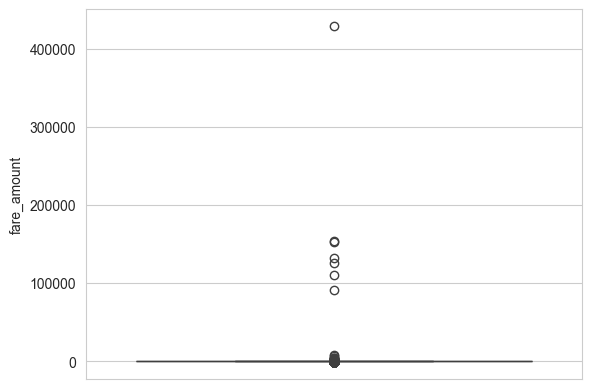

In [32]:
sns.boxplot(df_final.loc[:,"fare_amount"].compute())

In [35]:
percentile_values = np.arange(0.1,1.1,0.1)
quantiles=df_final['fare_amount'].quantile(q=percentile_values).compute()
for q,val in zip(percentile_values,quantiles):
    print(f"The fare amount value for {int(q * 100)}th percentile is {val:.2f}")

The fare amount value for 10th percentile is 5.00
The fare amount value for 20th percentile is 6.00
The fare amount value for 30th percentile is 7.50
The fare amount value for 40th percentile is 8.50
The fare amount value for 50th percentile is 10.00
The fare amount value for 60th percentile is 11.50
The fare amount value for 70th percentile is 14.00
The fare amount value for 80th percentile is 18.00
The fare amount value for 90th percentile is 27.00
The fare amount value for 100th percentile is 429496.72


In [37]:
percentile_values = np.arange(0.90,1.01,0.01)
quantiles=df_final['fare_amount'].quantile(q=percentile_values).compute()
for q,val in zip(percentile_values,quantiles):
    print(f"The fare amount value for {int(q * 100)}th percentile is {val:.2f}")

The fare amount value for 90th percentile is 27.00
The fare amount value for 91th percentile is 27.00
The fare amount value for 92th percentile is 28.00
The fare amount value for 93th percentile is 30.00
The fare amount value for 94th percentile is 32.50
The fare amount value for 95th percentile is 35.00
The fare amount value for 96th percentile is 40.00
The fare amount value for 97th percentile is 52.00
The fare amount value for 98th percentile is 52.00
The fare amount value for 99th percentile is 330.00
The fare amount value for 100th percentile is 429496.72


# RateCode ID

In [38]:
# unique values

rate_code_ids = (
    df_final.loc[:,"RatecodeID"]
    .value_counts()
    .compute()
)

In [39]:
rate_code_ids.sort_index()

RatecodeID
1.0     33627000
2.0       697595
3.0        56169
4.0        14459
5.0       103481
6.0          320
99.0         835
Name: count, dtype: int64

In [40]:
# unique values in rate code column

print(rate_code_ids.sort_index().index.tolist())

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0]


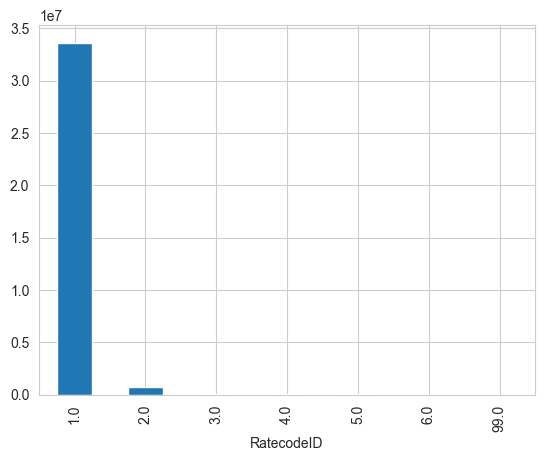

In [41]:
# plot the bar plot to display the distribution of categories

rate_code_ids.sort_index().plot(kind="bar")
plt.show()

Missing values category is replaced by 99

# Location Based Columns

In [42]:
# make a subset of location based columns

location_subset = df_final[['pickup_latitude','pickup_longitude', 
                           'dropoff_latitude','dropoff_longitude']]

location_subset

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
npartitions=82,,,,
,float64,float64,float64,float64
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


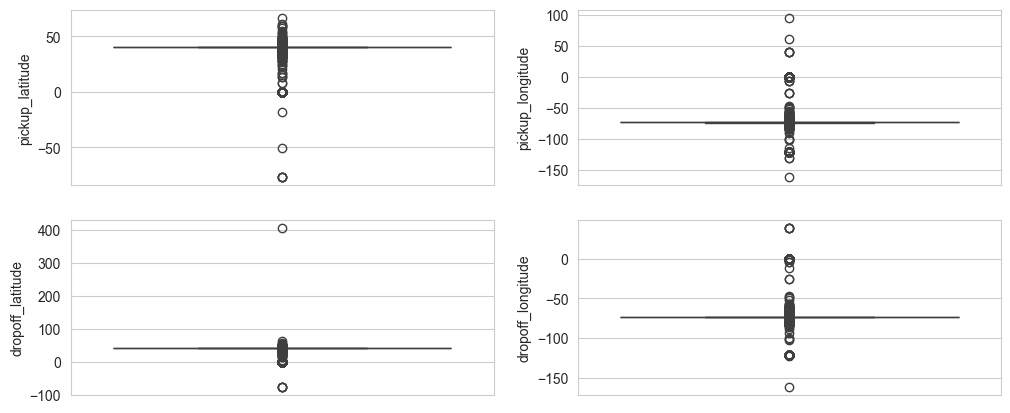

In [43]:
# boxplots for location based columns

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
for i in range(4):
    if i <= 1:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax1[i])
    else:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax2[i - 2])

# Store and Fwd Flag

store_and_fwd_flag
N    49769
Y      231
Name: count, dtype: int64[pyarrow]


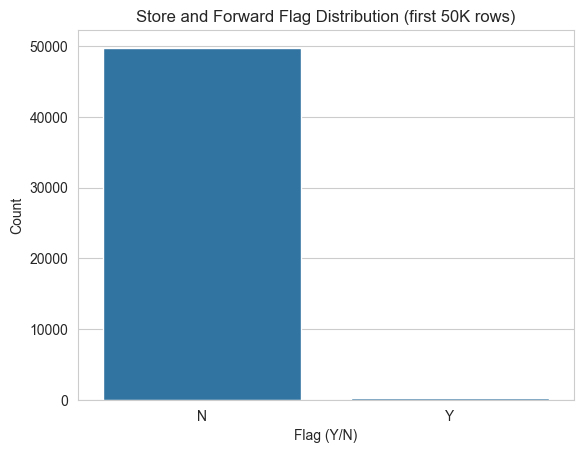

In [48]:
df_small = df_final.head(50000)  # reads only 50k rows
flag_counts = df_small["store_and_fwd_flag"].value_counts()
print(flag_counts)
sns.barplot(x=flag_counts.index, y=flag_counts.values)
plt.title("Store and Forward Flag Distribution (first 50K rows)")
plt.xlabel("Flag (Y/N)")
plt.ylabel("Count")
plt.show()

# Datetime Columns

In [52]:
df_final.columns


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='object')

In [53]:
# convert the columns to datetime

df_final["tpep_pickup_datetime"] = dd.to_datetime(df_final["tpep_pickup_datetime"], yearfirst=True, format="mixed")
df_final["tpep_dropoff_datetime"] = dd.to_datetime(df_final["tpep_dropoff_datetime"], yearfirst=True, format="mixed")

In [54]:
# create new columns

df_final["pickup_months"] = df_final["tpep_pickup_datetime"].dt.month
df_final["pickup_day_of_week"] = df_final["tpep_pickup_datetime"].dt.dayofweek
df_final["pickup_hour"] = df_final["tpep_pickup_datetime"].dt.hour

In [55]:
df_final

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount,pickup_months,pickup_day_of_week,pickup_hour
npartitions=82,,,,,,,,,,,,,,,
,float64,datetime64[ns],datetime64[ns],float64,float64,float64,float64,float64,string,float64,float64,float64,int32,int32,int32
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [56]:
df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount', 'pickup_months',
       'pickup_day_of_week', 'pickup_hour'],
      dtype='object')

In [57]:
df_final.dtypes

VendorID                         float64
tpep_pickup_datetime      datetime64[ns]
tpep_dropoff_datetime     datetime64[ns]
passenger_count                  float64
trip_distance                    float64
pickup_longitude                 float64
pickup_latitude                  float64
RatecodeID                       float64
store_and_fwd_flag       string[pyarrow]
dropoff_longitude                float64
dropoff_latitude                 float64
fare_amount                      float64
pickup_months                      int32
pickup_day_of_week                 int32
pickup_hour                        int32
dtype: object

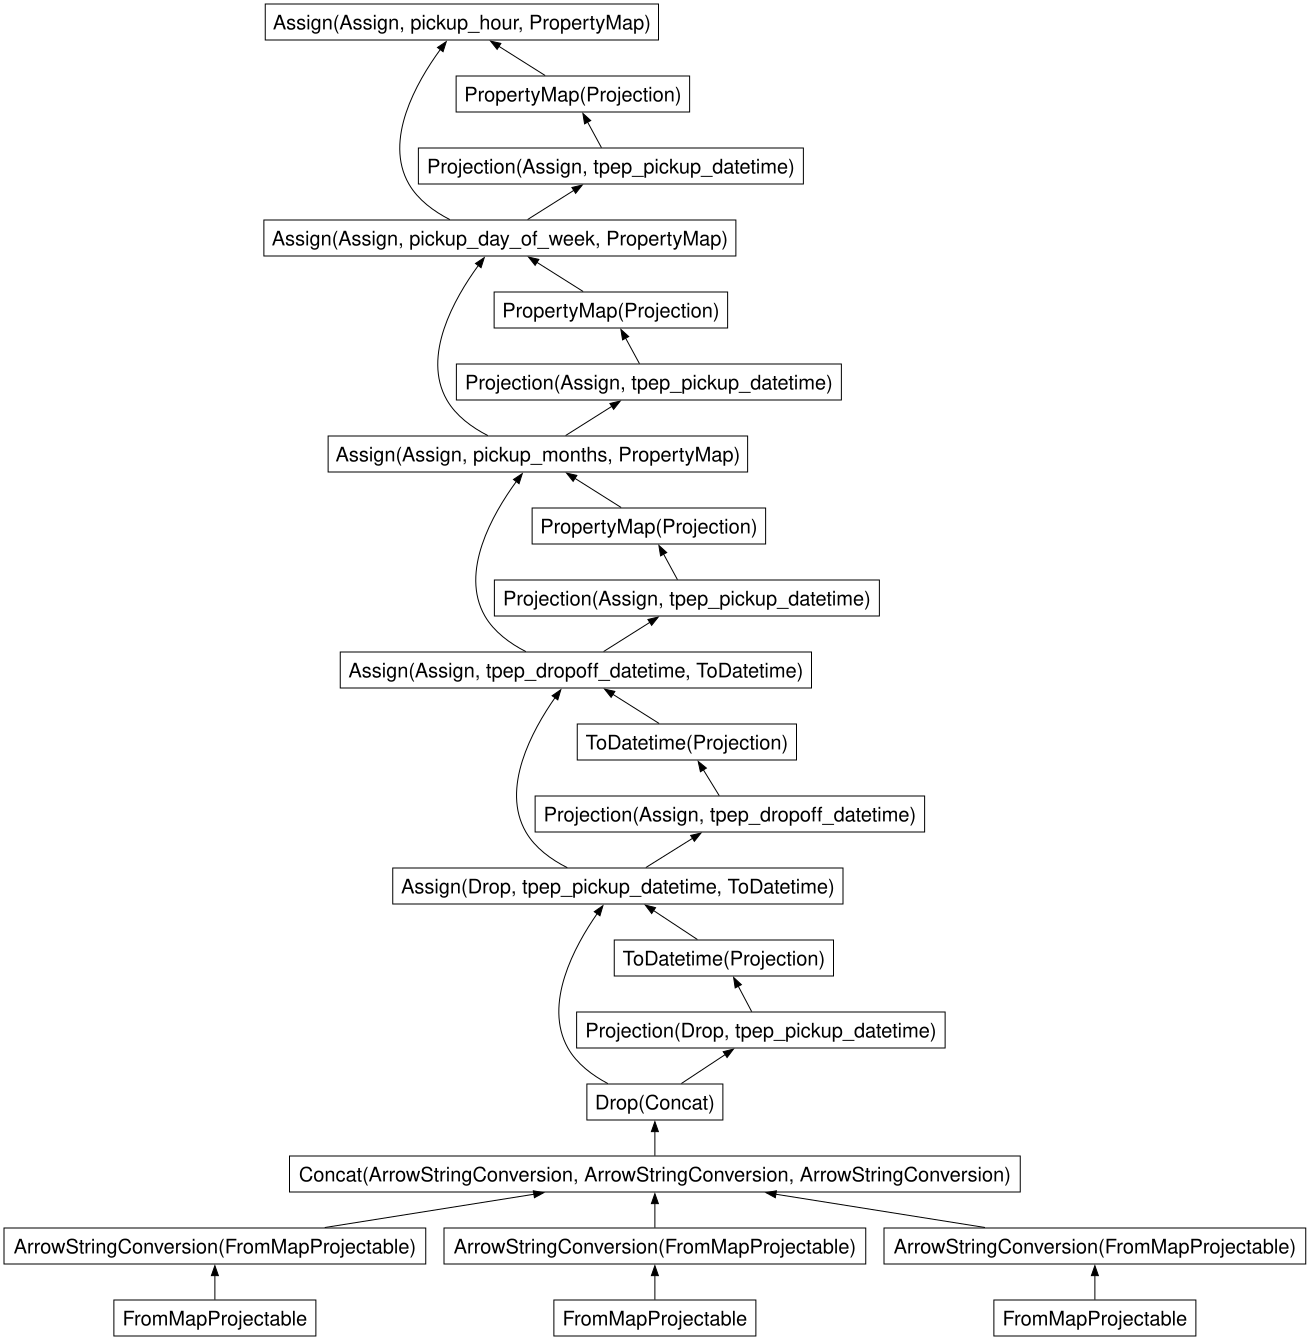

In [58]:
df_final.visualize()

In [59]:
# plot the number of pickups

pickups_every_3_days = (
                            df_final
                            .set_index('tpep_pickup_datetime')
                            .resample("3D")
                            .size()
                            .compute()
)

KeyboardInterrupt: 

In [60]:
df_sample = df_final.sample(frac=0.01, random_state=42)
pickups_every_3_days = (
    df_sample
    .assign(period=df_sample["tpep_pickup_datetime"].dt.floor("3D"))
    .groupby("period")
    .size()
    .compute()
)


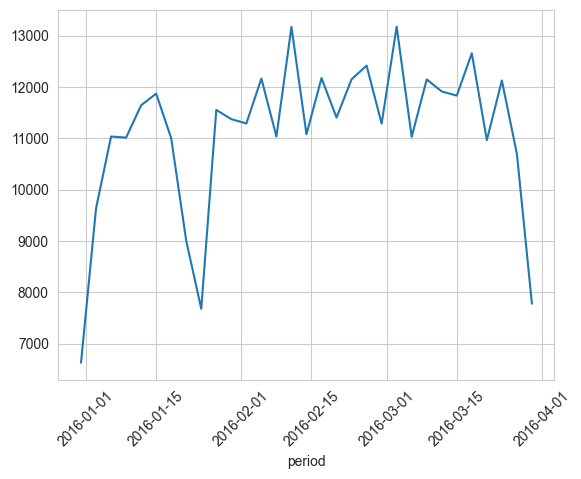

In [61]:

sns.lineplot(pickups_every_3_days)
plt.xticks(rotation=45)
plt.show()
    

In [63]:
df_sample = df_final.sample(frac=0.01, random_state=42)

# 📅 Compute total pickups every 3 days
pickups_each_hour = (
    df_sample
    .groupby(["pickup_hour","pickup_day_of_week"])["VendorID"]
    .count()
    .compute()
)

In [67]:
pickups_each_hour

,pickup_hour,pickup_day_of_week,Number of Pickups
0,3.0,4.0,750
1,12.0,4.0,2455
2,21.0,4.0,3072
3,12.0,6.0,2581
4,21.0,5.0,2537
...,...,...,...
163,7.0,3.0,2475
164,12.0,2.0,2359
165,12.0,3.0,2435
166,13.0,2.0,2292


In [65]:

pickups_each_hour = pickups_each_hour.reset_index()

In [66]:
pickups_each_hour.rename(columns={"VendorID":"Number of Pickups"},inplace=True)

In [68]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

replacement_mapper = {k:v for k,v in enumerate(day_names)}

replacement_mapper

{0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

In [69]:
pickups_each_hour.replace({"pickup_day_of_week":replacement_mapper},inplace=True)

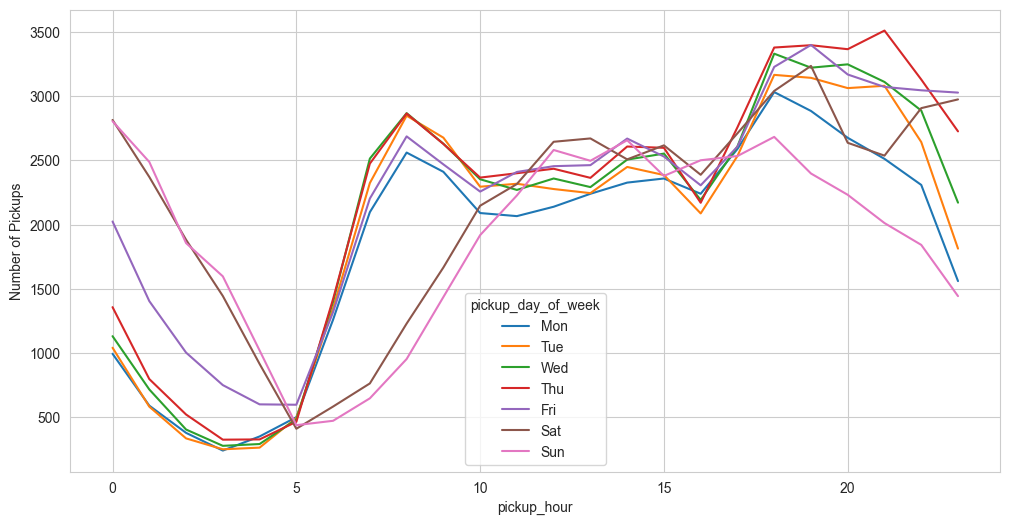

In [70]:
# plot the lineplot

fig = plt.figure(figsize=(12,6))

sns.lineplot(pickups_each_hour, x="pickup_hour", y="Number of Pickups", 
             hue="pickup_day_of_week",hue_order=day_names)

plt.show()